In [1]:
# Practice in Methods of Solving Nonlinear Equations: Relaxation, Binary, Newton

In [21]:
import numpy as np

def h(x, a=1.0):
    # Rearranged eq 1: y*(x^2+a) = x → y = x/(x^2+a)
    return x / (x**2 + a)

def k(y, a=1.0, b=2.0):
    # Rearranged eq 2: x = sqrt(b/y - a)
    val = b/y - a
    if val < 0:
        raise ValueError(f"Negative sqrt argument: b/y - a = {val:.4f}")
    return np.sqrt(val)

def rel_meth(func_y, func_x, xg=1.5, eps=1e-5, max_steps=1000):
    x = xg
    for step in range(max_steps):
        y_new = func_y(x)      # get y from current x
        x_new = func_x(y_new)  # get new x from y
        
        if abs(x_new - x) < eps:
            print(f"Converged in {step + 1} steps!")
            return x_new, y_new
        
        x = x_new
    
    print("Failed to converge")
    return x, func_y(x)

x_sol, y_sol = rel_meth(h, k)
print(f"Solution: x = {x_sol:.6f}, y = {y_sol:.6f}")
# Should give x = 2.000000, y = 0.400000

Converged in 12 steps!
Solution: x = 1.999996, y = 0.400001


In [28]:
# Binary Search (Bisection) Method:

# function with a known root at x = 1

def f(x):
    return x**3 + x -2 

def binary_search(func,x1,x2):
    eps = 1e-10
    N = 50
        
    for _ in range(N):
    
        f1,f2 = func(x1), func(x2)
        
        if f1*f2>0:
            return str("Same sign starting points")
            
        # calc the midpoint:
        mid = (x1+x2)*0.5
        f3 = func(mid)
    
        # if x3 has same sign as
        if np.sign(f1) == np.sign(f3):
            x1 = mid
        else:
            x2=mid
    
        if abs(x1-x2)<eps:
            return mid
            
    return str(f"Did not converge in {N} steps")

binary_search(f,0.1,5)
    

1.000000000027649

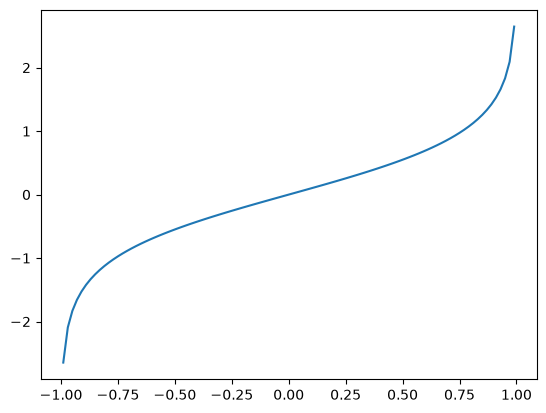

In [31]:
# Newton's Method: Example 6.4

"""
Newton's method to find roots for the inverse hyperbolic tangent
arctanh(u) = x or u = tanh(x), we will use the form tanh(x)-u = 0
and the derivative is 1/(cosh(x)^2) which we use in the formula:
x' = x-dx=x-f(x)/f'(x)
"""

from math import tanh,cosh
from numpy import linspace
from pylab import plot, show

accuracy = 1e-12

def arctanh(u):
    x = 0.0 # initial guess
    delta = 1.0
    while abs(delta)>accuracy:
        delta = (tanh(x)-u)*cosh(x)**2
        x -= delta
    return x

upoints = linspace(-0.99,0.99,100)
xpoints = []

for u in upoints:
    xpoints.append(arctanh(u))
plot(upoints,xpoints)
show()
        

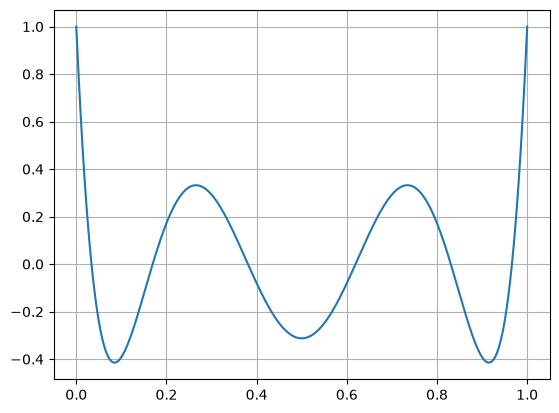

Converged: x = 0.03376524289842398
Converged: x = 0.1693953067668678
Converged: x = 0.3806904069583992
Converged: x = 0.6193095930415989
Converged: x = 0.8306046932331339
Converged: x = 0.9662347571015888
[0.03376524289842398, 0.1693953067668678, 0.3806904069583992, 0.6193095930415989, 0.8306046932331339, 0.9662347571015888]


In [42]:
# Newton for the roots of a degree 6 polynomial:

import numpy as np
from pylab import plot, show, grid

p =  np.poly1d([924,-2772,3150,-1680,420,-42,1])



z = np.linspace(0,1,500)
wpoints = p(z)

plot(z,wpoints)
grid()
show()

def newton_method(x, delta=1,accuracy=1e-11,steps=1000):

    for _ in range(steps):
        delta = p(x)*(1/p.deriv()(x))
        x -= delta
    
        if abs(delta) < accuracy:
            print(f"Converged: x = {x}")
            break
    else:
        return None
    return x 
    

# code for the six roots of the polynomial:
m = linspace(0,1,6)
roots = []
for i in m:
    roots.append(float(newton_method(i))) 

    
print(roots)

